In [70]:
from file_reader import CSVReader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import svm
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from collections import Counter
import re
from matplotlib import pyplot as plt
import seaborn as sns # for nice visualizations


reader = CSVReader()
recordings = reader.get_data_files_as_df()


def convert_gyro_data():
    need_gyro_conversion = ["lennart", "maximilian"]
    for recording in recordings:
        if recording["name"] in need_gyro_conversion:
            recording["data"]["gyro_x"] = np.deg2rad(recording["data"]["gyro_x"])
            recording["data"]["gyro_y"] = np.deg2rad(recording["data"]["gyro_y"])
            recording["data"]["gyro_z"] = np.deg2rad(recording["data"]["gyro_z"])


def split_recordings_to_train_test(whole_set):
    training, test = train_test_split(
        whole_set,
        test_size=0.2,
        stratify=[
            f"{r['activity']}_{r['name']}_{r['sensor_placement']}_{r['sample_rate']}"
            for r in recordings
        ],
    )
    return training, test


def create_time_windows(recordings, window_length):
    windows = []

    for rec in recordings:
        data = rec["data"]
        activity = rec["activity"]
        sample_rate = int(rec["sample_rate"].replace("hz", ""))
        window_size = sample_rate * window_length

        window_start = 0
        window_end = window_size

        while window_end <= len(data):
            window = data.iloc[window_start:window_end].copy()
            window["activity"] = activity
            window["sample"] = sample_rate
            windows.append(window)

            window_start += window_size
            window_end += window_size

    return windows


def transform_windows_to_features(windows):
    feature_rows = []
    
    for window in windows:
        feature_row = {}
        
        feature_row["activity"] = window["activity"].iloc[0]
        
        for acc_col in ["acc_x", "acc_y", "acc_z"]:
            feature_row[f"{acc_col}_mean"] = window[acc_col].mean()
            feature_row[f"{acc_col}_std"] = window[acc_col].std()
            feature_row[f"{acc_col}_min"] = window[acc_col].min()
            feature_row[f"{acc_col}_max"] = window[acc_col].max()

        for gyro_col in ["gyro_x", "gyro_y", "gyro_z"]:
            feature_row[f"{gyro_col}_mean"] = window[gyro_col].mean()
            feature_row[f"{gyro_col}_std"] = window[gyro_col].std()
            feature_row[f"{gyro_col}_min"] = window[gyro_col].min()
            feature_row[f"{gyro_col}_max"] = window[gyro_col].max()

        acc_strengths = np.sqrt(window["acc_x"]**2 + window["acc_y"]**2 + window["acc_z"]**2)
        gyro_strengths = np.sqrt(window["gyro_x"]**2 + window["gyro_y"]**2 + window["gyro_z"]**2)
        
        feature_row["acc_strenght_mean"] = acc_strengths.mean()
        feature_row["acc_strenght_std"] = acc_strengths.std()
        
        feature_row["gyro_strenght_mean"] = gyro_strengths.mean()
        feature_row["gyro_strenght_std"] = gyro_strengths.std()
        
        signal = acc_strengths - acc_strengths.mean()
        signal_hamming = signal * np.hamming(len(signal))
        acc_fft = np.fft.rfft(signal_hamming)
        acc_freqs = np.fft.rfftfreq(len(signal_hamming), 1/window["sample"].iloc[0])
        #magnitudes = np.abs(acc_fft)
        #dominant_freq_index = np.argmax(magnitudes[1:]) + 1  # Skip the zero frequency component
        #feature_row["acc_dom_freq"] = acc_freqs[dominant_freq_index]
        feature_row["acc_dom_freq"] = acc_freqs[np.argmax(np.abs(acc_fft))]
        
        
        signal = gyro_strengths - gyro_strengths.mean()
        signal_hamming = signal * np.hamming(len(signal))
        gyro_fft = np.fft.rfft(signal_hamming)
        gyro_freqs = np.fft.rfftfreq(len(signal_hamming), 1/window["sample"].iloc[0]) 
        feature_row["dom_gyro_freq"] = gyro_freqs[np.argmax(np.abs(gyro_fft))]
        
        feature_rows.append(feature_row)
    
    classifier_data = pd.DataFrame(feature_rows)
    return classifier_data


def perform_standard_scaling(train_df, df_to_scale):
    scaler = StandardScaler()
    scaler.fit(train_df[[col for col in train_df.columns if col != "activity"]])
    scaled_samples =  scaler.transform(df_to_scale[[col for col in df_to_scale.columns if col != "activity"]])
    df_scaled = df_to_scale.copy()
    df_scaled[[col for col in df_scaled.columns if col != "activity"]] = scaled_samples
    return df_scaled

def perform_normalization(train_df, df_to_normalize):
    scaler = MinMaxScaler()
    scaler.fit(train_df[[col for col in train_df.columns if col != "activity"]])
    scaled_samples = scaler.transform(df_to_normalize[[col for col in df_to_normalize.columns if col != "activity"]])
    df_normalized = df_to_normalize.copy()
    df_normalized[[col for col in df_normalized.columns if col != "activity"]] = scaled_samples
    return df_normalized

convert_gyro_data()

train_recordings, test_recording = split_recordings_to_train_test(recordings)
# split before standardi

WINDOW_LENGTH = 2

train_windows = create_time_windows(train_recordings, WINDOW_LENGTH)
test_windows = create_time_windows(test_recording, WINDOW_LENGTH)

classifier_train_data = transform_windows_to_features(train_windows)
classifier_test_data = transform_windows_to_features(test_windows)

standard_scaled_train = perform_standard_scaling(classifier_train_data, classifier_train_data)
normalized_train = perform_normalization(standard_scaled_train, standard_scaled_train )

standard_scaled_test = perform_standard_scaling(classifier_train_data, classifier_test_data)
normalized_test = perform_normalization(standard_scaled_train, standard_scaled_test)


# classifier mit normalized_train und normalized_test trainieren usw


In [35]:
standard_scaled_test

,activity,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_y_mean,acc_y_std,acc_y_min,acc_y_max,acc_z_mean,...,gyro_z_mean,gyro_z_std,gyro_z_min,gyro_z_max,acc_strenght_mean,acc_strenght_std,gyro_strenght_mean,gyro_strenght_std,acc_dom_freq,dom_gyro_freq
0,running,0.207080,-0.209892,0.173763,0.162608,-0.981746,0.348501,-0.992186,-0.793785,-0.102779,...,0.006036,-0.244596,0.223531,-0.223381,-0.435265,0.319958,-0.255736,-0.245827,0.059004,0.770194
1,running,0.156624,-0.181537,-0.090908,0.464726,-1.072708,0.264103,-1.638166,-0.620460,-0.046924,...,0.072382,-0.236354,0.215858,-0.229385,-0.354655,0.311129,-0.250540,-0.238473,0.059004,-0.240357
2,running,0.178963,-0.228195,0.089670,0.185698,-1.129565,0.321247,-1.225021,-0.843226,0.005786,...,0.040080,-0.240829,0.204959,-0.223378,-0.358753,0.285927,-0.255992,-0.247207,0.295556,-0.240357
3,running,0.189137,-0.308295,0.162625,0.070773,-1.010246,0.182745,-0.964158,-0.826435,-0.023852,...,0.071130,-0.254387,0.231565,-0.238024,-0.447960,0.160399,-0.257216,-0.244637,0.295556,0.433344
4,lifting,0.506757,-0.080045,0.421762,0.033497,-0.032513,-0.527844,0.404466,-0.485802,0.623721,...,0.018770,-0.266504,0.252646,-0.264114,-0.162364,-0.206426,-0.227166,-0.239050,-0.887205,-0.240357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,lifting,-0.399301,-0.155740,0.199690,-0.257073,0.313515,-0.078730,0.251359,0.013088,0.270669,...,0.002787,-0.215144,0.226618,-0.227518,-0.459478,-0.382022,-0.256280,-0.247738,-0.414101,-0.577208
768,lifting,-0.520106,-0.438448,0.285310,-0.519127,0.200689,0.024122,0.301123,-0.009859,0.321914,...,-0.008560,-0.222304,0.223346,-0.248303,-0.515967,-0.502781,-0.257526,-0.252903,-0.414101,-0.577208
769,lifting,-0.385807,-0.337538,0.176858,-0.380078,0.217169,0.071782,0.206118,-0.071051,0.156053,...,0.028900,-0.212105,0.226075,-0.226809,-0.540299,-0.514593,-0.251933,-0.253116,-0.650653,-0.577208
770,lifting,-0.318015,-0.224427,0.285310,-0.267769,0.160439,0.237852,0.228739,-0.025157,0.104808,...,0.018357,-0.198752,0.203636,-0.225158,-0.526082,-0.474317,-0.253139,-0.242661,-0.650653,-0.577208


<Axes: xlabel='acc_x_mean', ylabel='gyro_x_mean'>

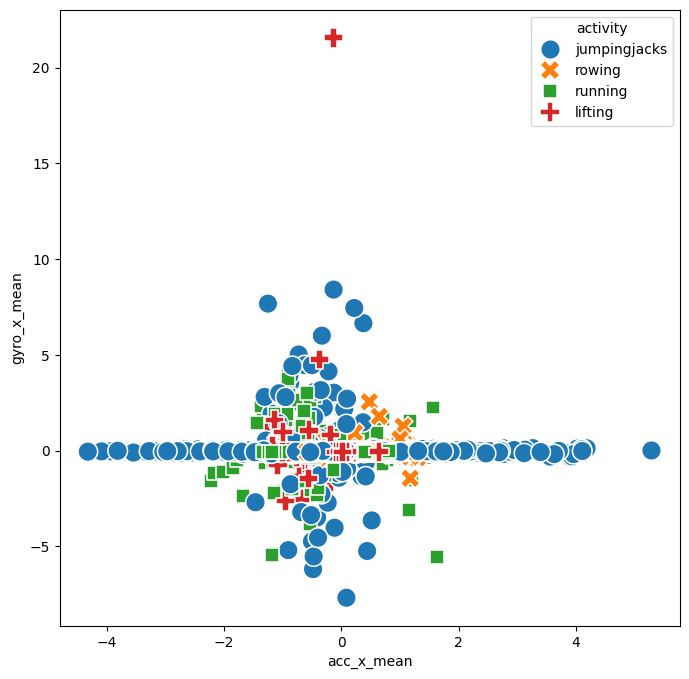

In [36]:
fig = plt.figure(figsize=(8, 8))

sns.scatterplot(data=standard_scaled_train, x='acc_x_mean', y='gyro_x_mean', hue='activity', style='activity', s=200)

<Axes: xlabel='acc_strenght_mean', ylabel='gyro_strenght_mean'>

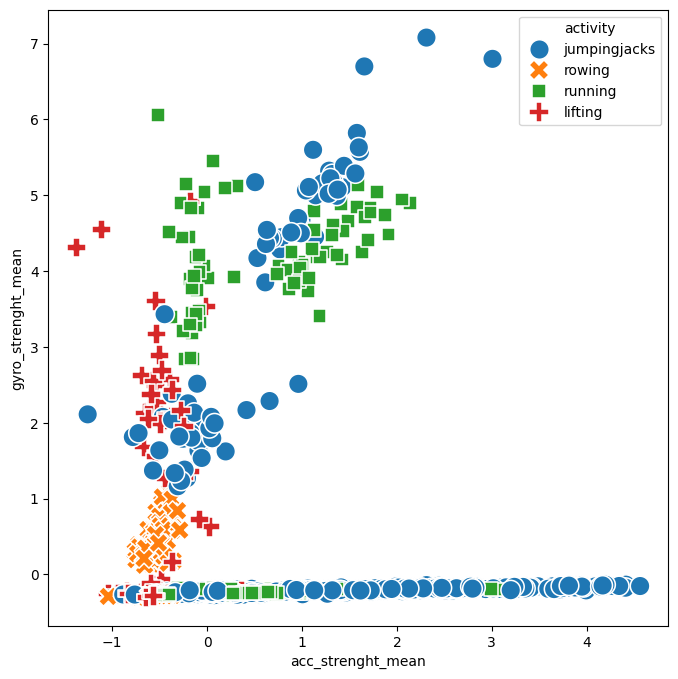

In [37]:
fig = plt.figure(figsize=(8, 8))

sns.scatterplot(data=standard_scaled_train, x='acc_strenght_mean', y='gyro_strenght_mean', hue='activity', style='activity', s=200)

<Axes: xlabel='acc_dom_freq', ylabel='dom_gyro_freq'>

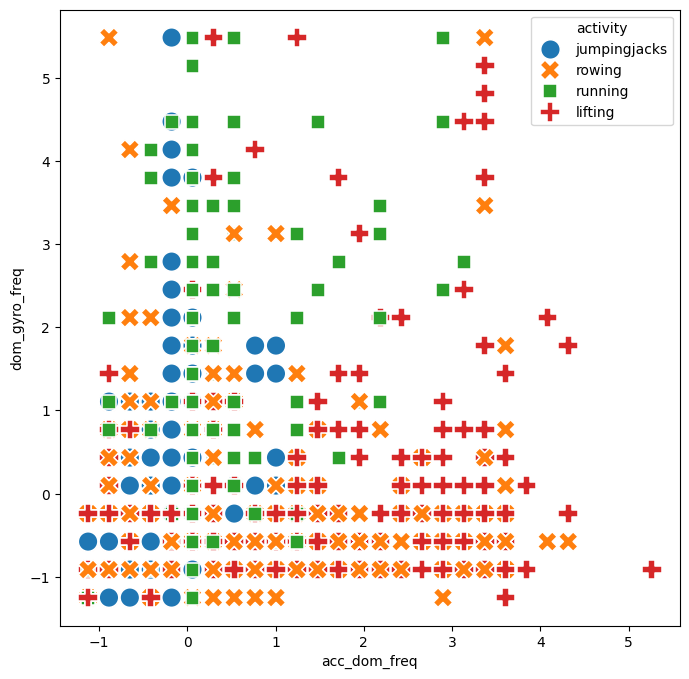

In [38]:
fig = plt.figure(figsize=(8, 8))

sns.scatterplot(data=standard_scaled_train, x='acc_dom_freq', y='dom_gyro_freq', hue='activity', style='activity', s=200)

In [44]:
x_train = standard_scaled_train.drop(columns=["activity"])
y_train = standard_scaled_train["activity"]

x_test = standard_scaled_test.drop(columns=["activity"])
y_test = standard_scaled_test["activity"]

In [48]:
def train_and_evaluate(classifier, features_train, classes_train, features_test, classes_test):
    classifier.fit(features_train, classes_train)

    # Predict test data
    classes_predicted = classifier.predict(features_test)

    # Calculate accuracy
    accuracy = accuracy_score(classes_test, classes_predicted)
    return classes_predicted, accuracy

In [76]:
def plot_confusion_matrix(classes_test, classes_predicted, ax=None):
    conf_matrix = confusion_matrix(classes_test, classes_predicted)

    ConfusionMatrixDisplay(conf_matrix, display_labels=np.unique(classes_test)).plot(ax=ax)

    plt.xticks(rotation=90, ha='center')

In [90]:
def plot_classification_report(classes_test, classes_predicted):
    report = classification_report(classes_test, classes_predicted, output_dict=True)
    df = pd.DataFrame(report)
    return df

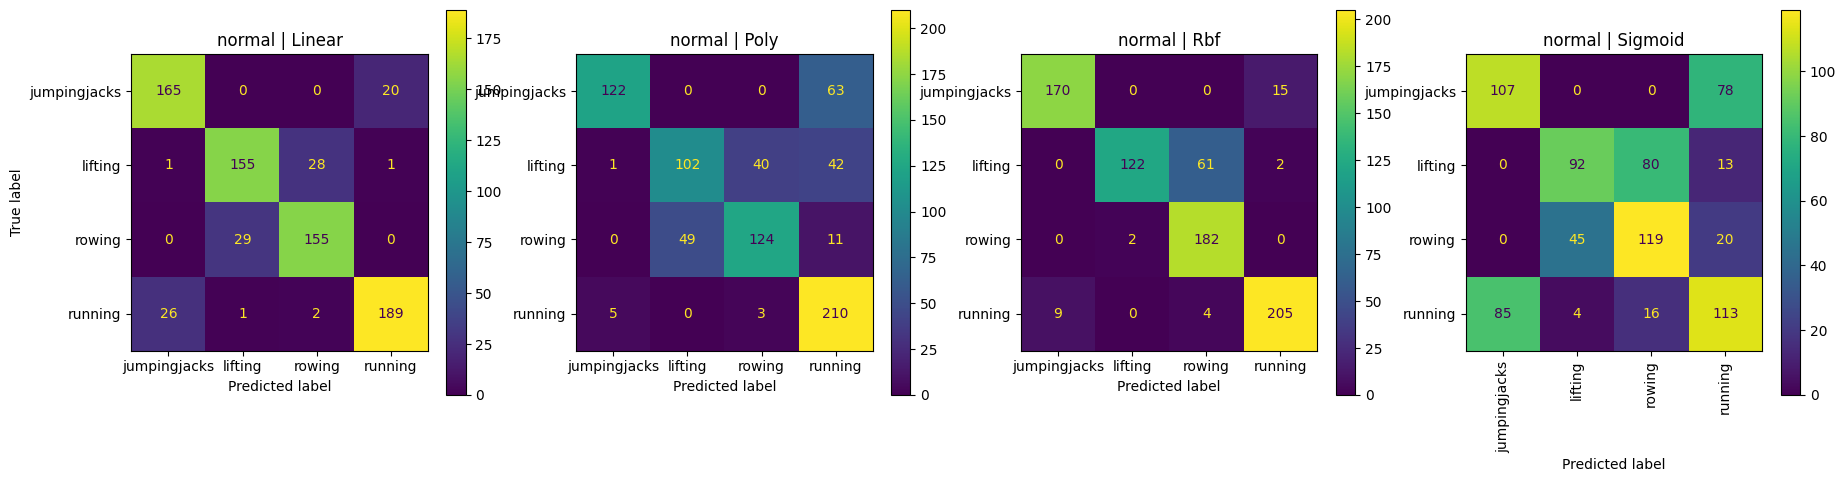

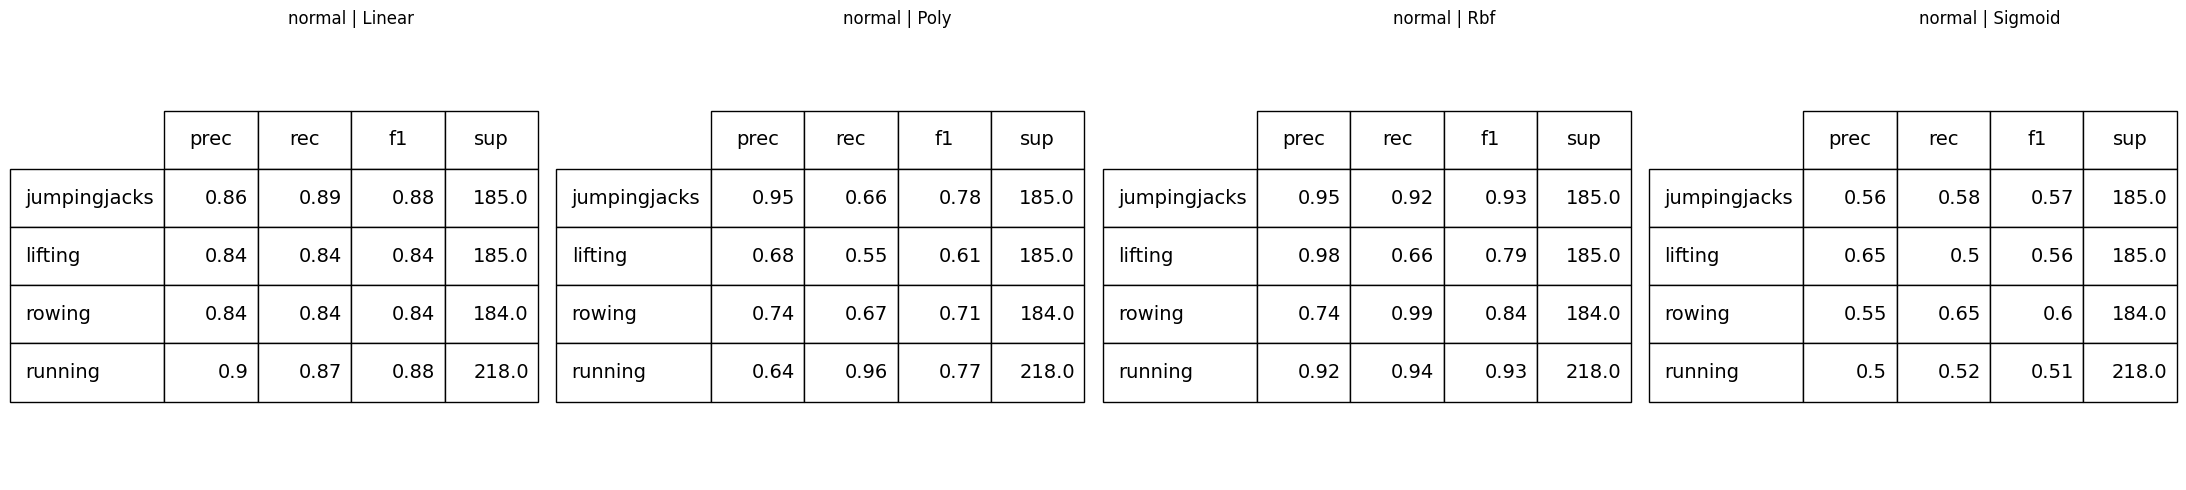

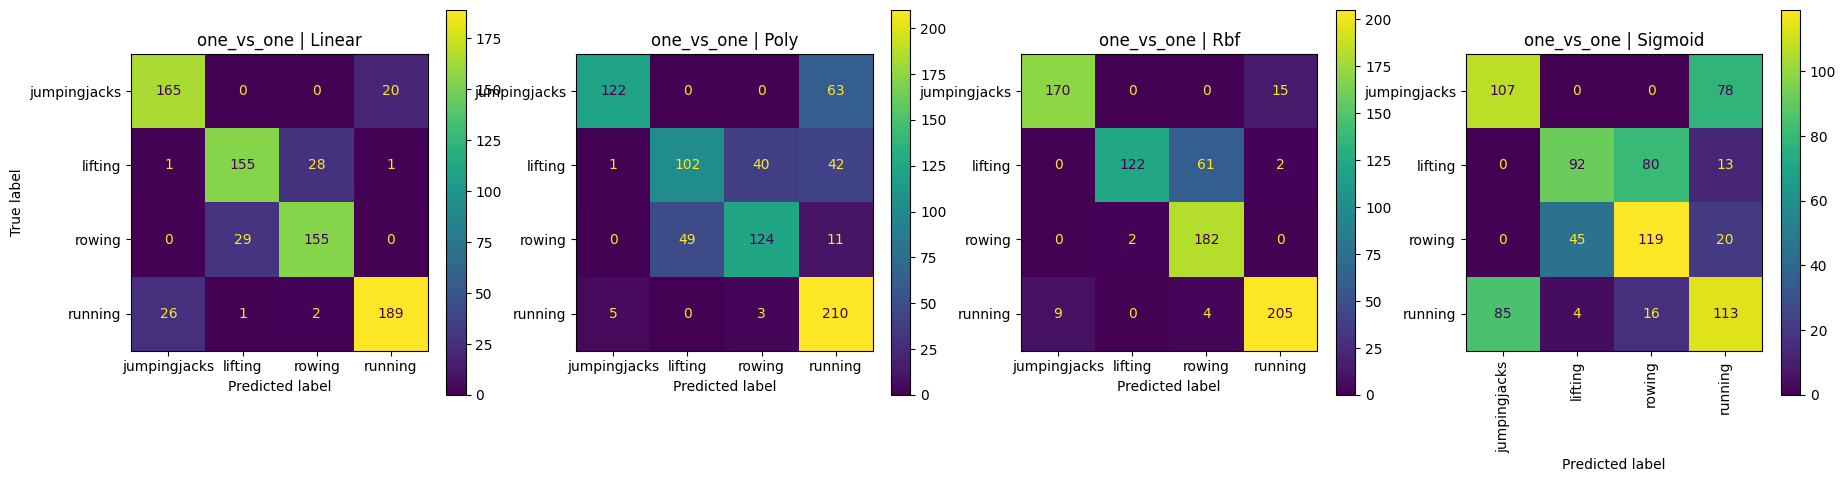

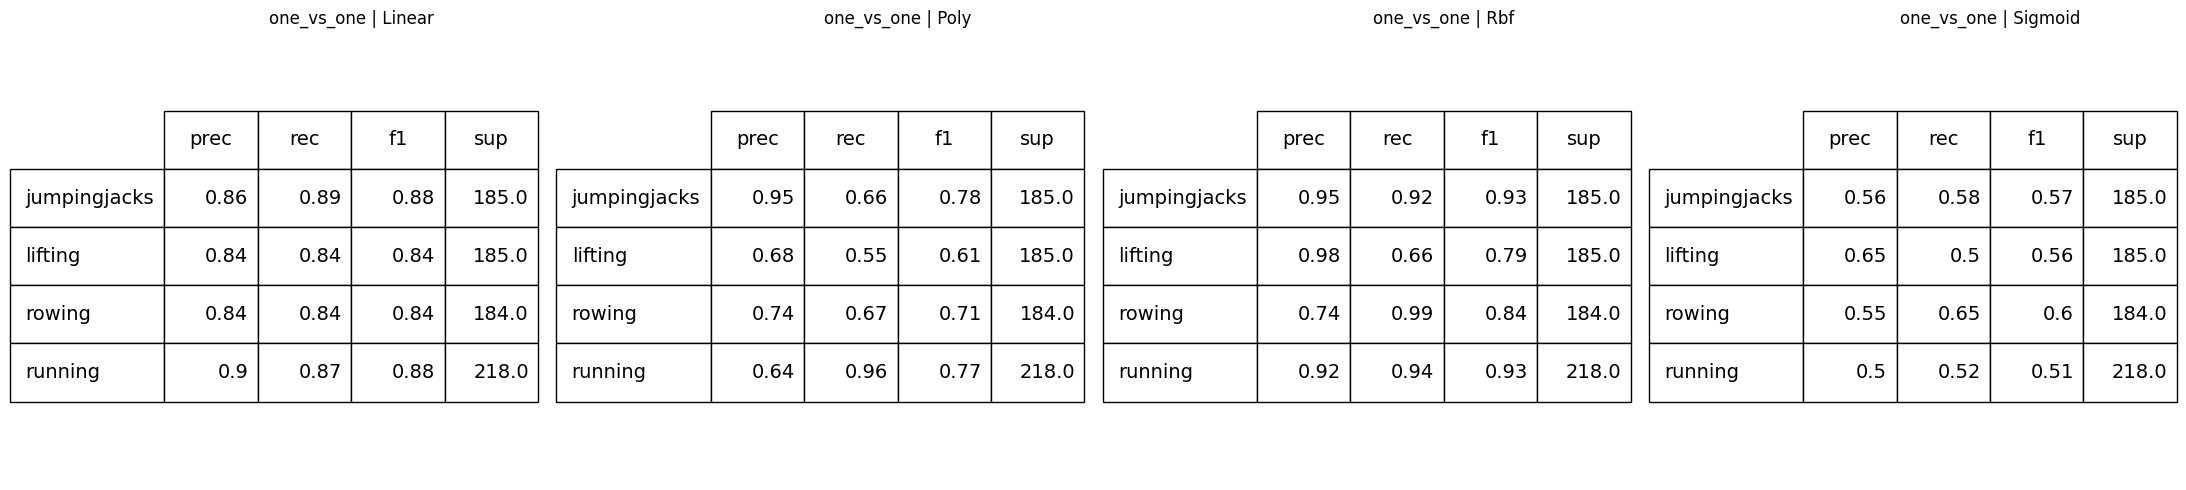

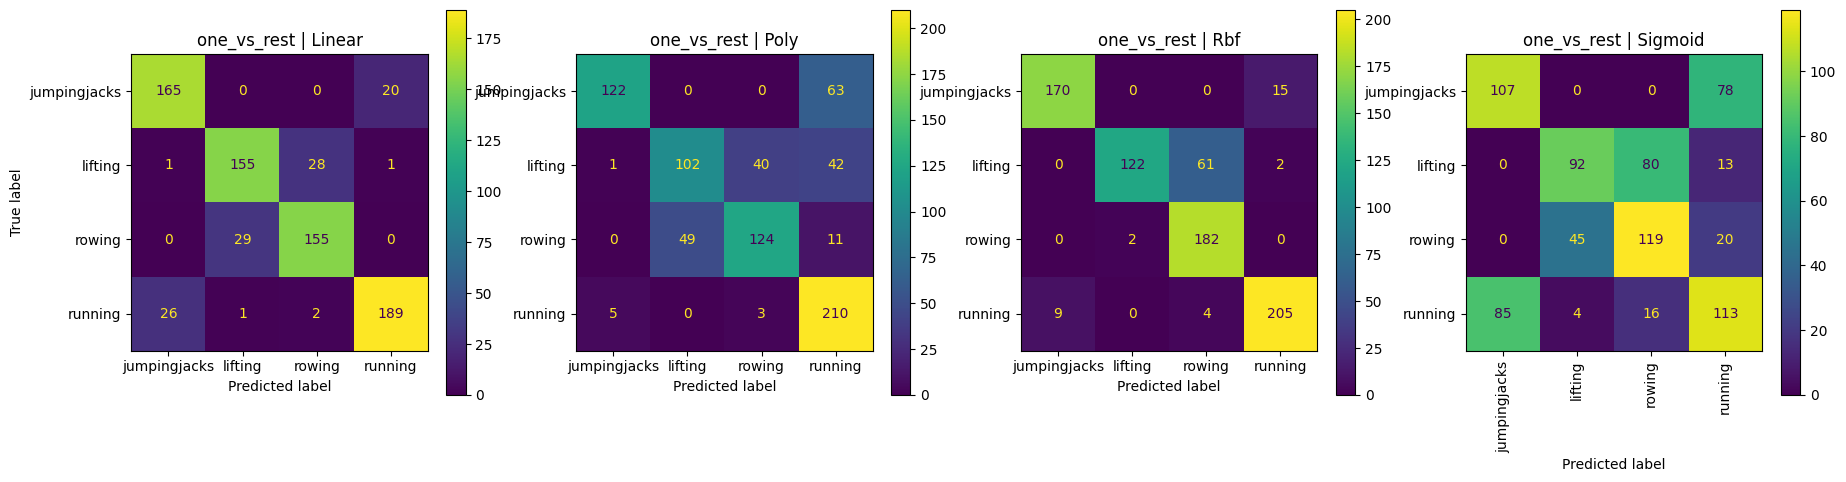

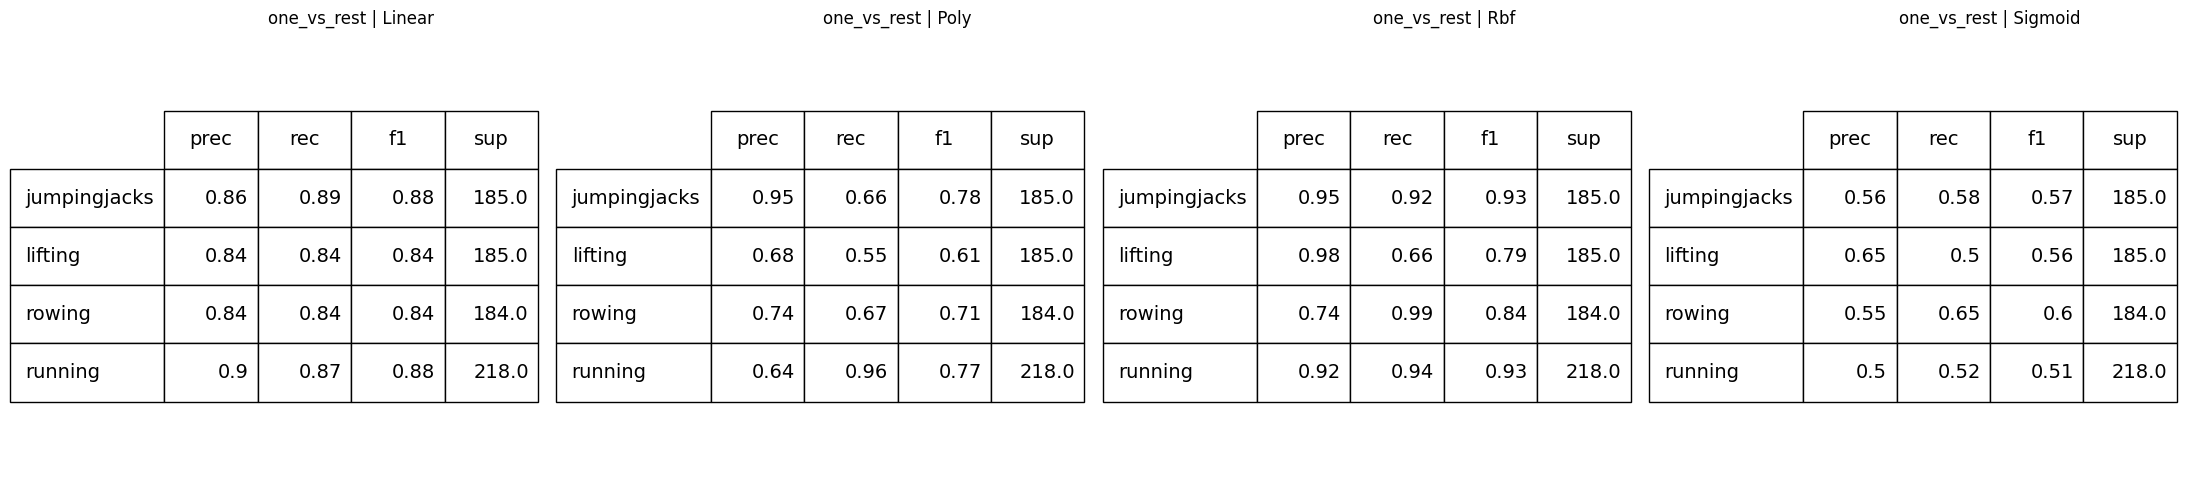

In [ ]:
strategies = {
    "normal": lambda kernel: svm.SVC(kernel=kernel),
    "one_vs_one": lambda kernel: OneVsOneClassifier(svm.SVC(kernel=kernel)),
    "one_vs_rest": lambda kernel: OneVsRestClassifier(svm.SVC(kernel=kernel)),
}

classifiers = []
predictions_list = []

for strategy_name, function in strategies.items():
    for selected_kernel in ["linear", "poly", "rbf", "sigmoid"]:
        classifier = function(selected_kernel)
        classifiers.append(classifier)
        predictions, accuracy = train_and_evaluate(classifier, x_train, y_train, x_test, y_test)
        predictions_list.append(predictions)
        print(f"{strategy_name} | {selected_kernel.capitalize()} | Accuracy: {accuracy:.4f}")
        
        report_df = plot_classification_report(y_test, predictions).drop(columns=["macro avg", "weighted avg", "accuracy"]).round(3).transpose()
        
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    for i, selected_kernel in enumerate(["linear", "poly", "rbf", "sigmoid"]):
        plot_confusion_matrix(y_test, predictions_list[i], ax=axes[i])
        axes[i].set_title(f"{strategy_name} | {selected_kernel.capitalize()}")

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    for i, selected_kernel in enumerate(["linear", "poly", "rbf", "sigmoid"]):
        report_df = plot_classification_report(y_test, predictions_list[i]).drop(columns=["macro avg", "weighted avg", "accuracy"]).round(2).transpose()
        report_df.columns = ["prec", "rec", "f1", "sup"]
        axes[i].axis("off")
        table = axes[i].table(
            cellText=report_df.values,
            colLabels=report_df.columns,
            rowLabels=report_df.index,
            loc='center'
        )
        axes[i].set_title(f"{strategy_name} | {selected_kernel.capitalize()}")
        table.auto_set_font_size(False)
        table.set_fontsize(14)
        table.scale(1.1, 3)


    plt.tight_layout()
    